In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import seaborn as sns
from features import common_preprocessing, get_datasets
from utils import process_fx


In [3]:
X_train, Y_train = get_datasets()
target_pairs = pd.read_csv("data/target_pairs.csv")


Dropping columns:  ['US_Stock_GOLD_adj_open', 'US_Stock_GOLD_adj_high', 'US_Stock_GOLD_adj_low', 'US_Stock_GOLD_adj_close', 'US_Stock_GOLD_adj_volume', 'JPX_Gold_Mini_Futures_settlement_price', 'JPX_Gold_Rolling-Spot_Futures_settlement_price', 'JPX_Platinum_Mini_Futures_settlement_price', 'JPX_RSS3_Rubber_Futures_settlement_price']
Found 505 relevant columns
Only close column provided for stem lme_ah
Only close column provided for stem lme_ca
Only close column provided for stem lme_pb
Only close column provided for stem lme_zs


In [4]:
filtered = [col for col in X_train.columns if "volat" in col]
filtered


['jpx_gold_mini_futures_intraday_volatility',
 'jpx_gold_rolling-spot_futures_intraday_volatility',
 'jpx_gold_standard_futures_intraday_volatility',
 'jpx_platinum_mini_futures_intraday_volatility',
 'jpx_platinum_standard_futures_intraday_volatility',
 'jpx_rss3_rubber_futures_intraday_volatility',
 'us_stock_acwi_adj_intraday_volatility',
 'us_stock_aem_adj_intraday_volatility',
 'us_stock_ag_adj_intraday_volatility',
 'us_stock_agg_adj_intraday_volatility',
 'us_stock_alb_adj_intraday_volatility',
 'us_stock_amp_adj_intraday_volatility',
 'us_stock_bcs_adj_intraday_volatility',
 'us_stock_bkr_adj_intraday_volatility',
 'us_stock_bnd_adj_intraday_volatility',
 'us_stock_bndx_adj_intraday_volatility',
 'us_stock_bp_adj_intraday_volatility',
 'us_stock_bsv_adj_intraday_volatility',
 'us_stock_cat_adj_intraday_volatility',
 'us_stock_ccj_adj_intraday_volatility',
 'us_stock_clf_adj_intraday_volatility',
 'us_stock_cop_adj_intraday_volatility',
 'us_stock_cve_adj_intraday_volatility',
 

## Momentum and mean-reversion

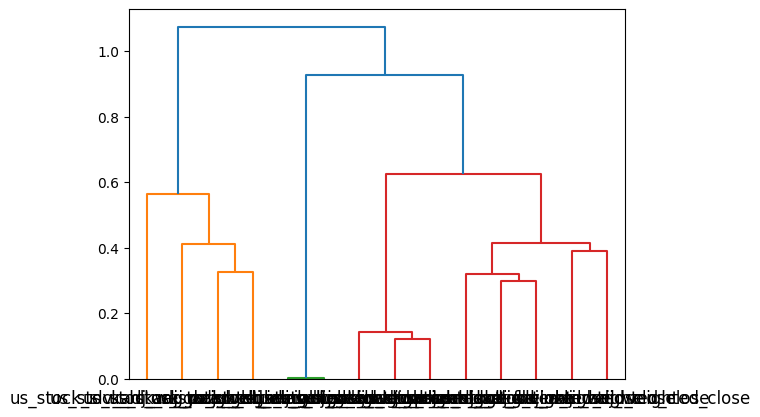

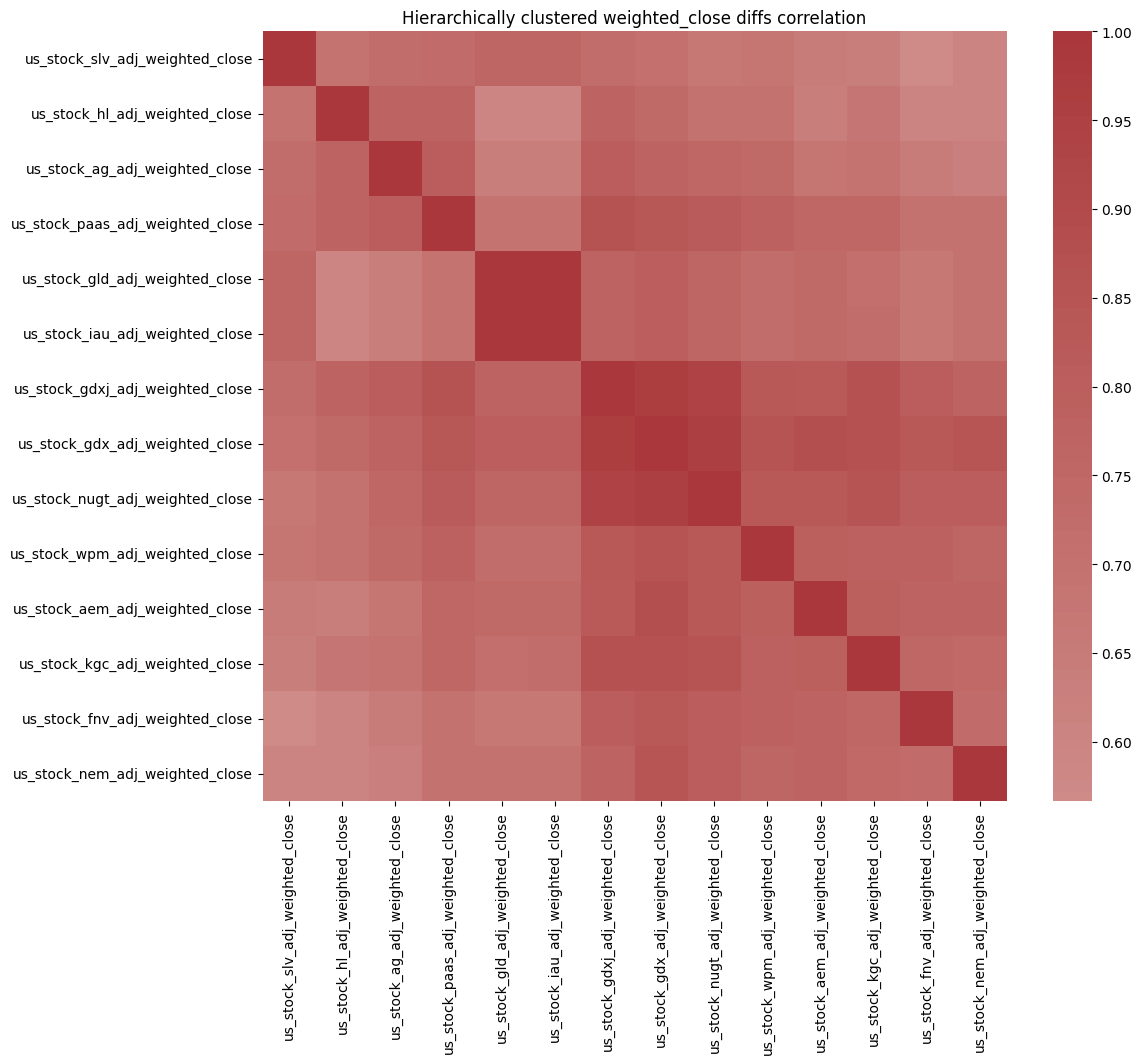

In [ ]:
X_close = X_train[
    [
        col
        for col in X_train.columns
        if any(col.startswith(prefix) for prefix in precious_metals)
        and "weighted_close" in col
    ]
]

# Take first differences (returns)
X_close_diff = X_close.fillna(0).diff().dropna()

# Compute correlation matrix
corr = X_close_diff.corr()

# Hierarchically order correlation matrix
import scipy.cluster.hierarchy as sch
import seaborn as sns

# Compute linkage (hierarchical clustering)
linkage = sch.linkage(corr, method="ward")
dendro = sch.dendrogram(linkage, no_plot=False, labels=corr.columns)
ordered_cols = dendro["ivl"]

# Reorder correlation matrix
corr_ordered = corr.loc[ordered_cols, ordered_cols]

# Plot
plt.figure(figsize=(12, 10))
sns.heatmap(corr_ordered, cmap="vlag", center=0)
plt.title("Hierarchically clustered weighted_close diffs correlation")
plt.show()


In [ ]:
print(ordered_cols)


['us_stock_enb_adj_weighted_close', 'us_stock_oke_adj_weighted_close', 'us_stock_trgp_adj_weighted_close', 'us_stock_kmi_adj_weighted_close', 'us_stock_wmb_adj_weighted_close', 'us_stock_cop_adj_weighted_close', 'us_stock_dvn_adj_weighted_close', 'us_stock_eog_adj_weighted_close', 'us_stock_hes_adj_weighted_close', 'us_stock_cve_adj_weighted_close', 'us_stock_oxy_adj_weighted_close', 'us_stock_xle_adj_weighted_close', 'us_stock_slb_adj_weighted_close', 'us_stock_hal_adj_weighted_close', 'us_stock_oih_adj_weighted_close', 'us_stock_bp_adj_weighted_close', 'us_stock_shel_adj_weighted_close', 'us_stock_mpc_adj_weighted_close', 'us_stock_bkr_adj_weighted_close', 'us_stock_cvx_adj_weighted_close', 'us_stock_xom_adj_weighted_close', 'us_stock_acwi_adj_weighted_close', 'us_stock_vt_adj_weighted_close', 'us_stock_vgk_adj_weighted_close', 'us_stock_vxus_adj_weighted_close', 'us_stock_efa_adj_weighted_close', 'us_stock_vea_adj_weighted_close', 'us_stock_xlb_adj_weighted_close', 'us_stock_rsp_adj

In [5]:
X_close = X_train.filter(like="weighted_close")
from numpy.linalg import svd

# Calculate first differences (returns)
X_close_diff = X_close.fillna(0).diff().fillna(0)
X_close_diff_np = X_close_diff.to_numpy()

# SVD on returns
U, S, VT = svd(X_close_diff_np, full_matrices=False)
k = 1
U_k = U[:, :k]
S_k = S[:k]
VT_k = VT[:k, :]

# Low-rank approximation of returns
X_close_diff_rank_k = (U_k * S_k) @ VT_k * 0

# Sum reconstructed returns back to price-like levels
X_close_rank_k_cumsum = pd.DataFrame(
    np.cumsum(X_close_diff_rank_k, axis=0), index=X_close.index, columns=X_close.columns
)

# Residuals in levels
X_close_residuals = X_close - X_close_rank_k_cumsum


In [72]:
momdict = {}

for col in X_close_residuals.columns:
    if not col.endswith("weighted_close"):
        continue
    stem = col.replace("_weighted_close", "")
    if stem not in precious_metals:
        continue
    if f"{stem}_intraday_volatility" not in X_train:
        continue
    close_values = X_close_residuals[col]
    rv = X_train[f"{stem}_intraday_volatility"].rolling(20).mean() ** 0.5
    momdict[f"{col}_rv"] = rv
    momdict[f"{col}_skew"] = close_values.rolling(5).skew()
    momdict[f"{col}_pos"] = X_train[f"{stem}_close_in_range"]
    momdict[f"{col}_r_day"] = X_train[f"{stem}_day_return"]
    momdict[f"{col}_r_night"] = X_train[f"{stem}_overnight_return"]
    momdict[f"{col}_r_1"] = close_values - close_values.shift(1)
    momdict[f"{col}_r_2_4"] = close_values.shift(1) - close_values.shift(4)
    momdict[f"{col}_next_1"] = close_values.shift(-1) - close_values
    momdict[f"{col}_next_2_4"] = close_values.shift(-4) - close_values.shift(-1)

momdf = pd.DataFrame(momdict).dropna()

momdf = (momdf - momdf.mean(axis=0)) / momdf.std(axis=0)
from sklearn.preprocessing import QuantileTransformer

# Apply QuantileTransformer (output_distribution='normal') to 'next_1' and 'next_2_4'
qt = QuantileTransformer(
    output_distribution="normal", random_state=0, n_quantiles=min(1000, len(momdf))
)
for col in ["next_1", "next_2_4"]:
    target_cols = [c for c in momdf.columns if c.endswith(col)]
    for c in target_cols:
        momdf[c] = qt.fit_transform(momdf[[c]])

momdf.shape


(1938, 126)

In [73]:
mom_concat = {}
for suffix in [
    "rv",
    "skew",
    "pos",
    "r_day",
    "r_night",
    "r_1",
    "r_2_4",
    "next_1",
    "next_2_4",
]:
    cols = [col for col in momdf.columns if col.endswith(suffix)]
    if cols:
        mom_concat[suffix] = pd.concat([momdf[col] for col in cols], ignore_index=True)
mom_concat = pd.DataFrame(mom_concat)
mom_concat.describe()


,rv,skew,pos,r_day,r_night,r_1,r_2_4,next_1,next_2_4
count,2.713200e+04,2.713200e+04,2.713200e+04,2.713200e+04,2.713200e+04,2.713200e+04,2.713200e+04,27132.000000,27132.000000
mean,3.613994e-17,2.880720e-18,-3.509241e-17,-2.815249e-18,2.880720e-18,-5.761440e-18,2.356953e-18,0.000044,-0.000035
std,9.997604e-01,9.997604e-01,9.997604e-01,9.997604e-01,9.997604e-01,9.997604e-01,9.997604e-01,1.009930,1.009748
min,-1.575705e+00,-2.399417e+00,-1.750670e+00,-1.681235e+01,-1.648639e+01,-1.163609e+01,-1.314705e+01,-5.199338,-5.199338
25%,-4.962993e-01,-6.648160e-01,-9.095443e-01,-5.213116e-01,-4.675807e-01,-5.018863e-01,-5.599208e-01,-0.674593,-0.674819
50%,-1.899808e-01,-5.567548e-03,2.448397e-02,7.313827e-03,1.840287e-02,-1.213683e-02,3.862012e-03,-0.005018,-0.000011
75%,2.541735e-01,6.543285e-01,9.101888e-01,5.338873e-01,5.063470e-01,5.203476e-01,5.678011e-01,0.674868,0.674559
max,8.735778e+00,2.511095e+00,1.659026e+00,1.534907e+01,1.226696e+01,9.864115e+00,7.600348e+00,5.199338,5.199338


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000177 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 255
[LightGBM] [Info] Number of data points in the train set: 21705, number of used features: 1
[LightGBM] [Info] Start training from score -0.000688


/Users/mike/.pyenv/versions/3.12.5/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


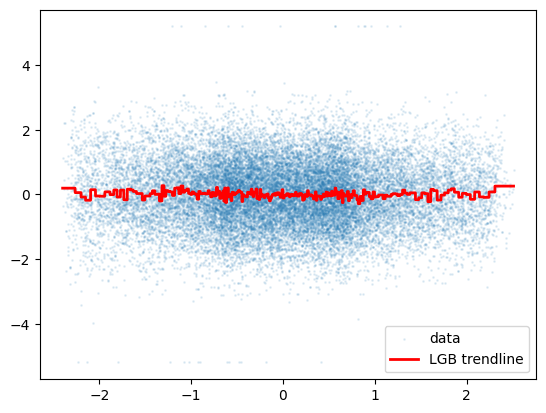

In [74]:
import lightgbm as lgb
import numpy as np
from sklearn.metrics import mean_squared_error

x_cur = mom_concat["skew"].values.reshape(-1, 1)
y_cur = mom_concat["next_2_4"].values

# Split into train/test for plotting a trendline (simple 80/20)
n_split = int(0.8 * len(x_cur))
x_train, x_test = x_cur[:n_split], x_cur[n_split:]
y_train, y_test = y_cur[:n_split], y_cur[n_split:]

lgbm = lgb.LGBMRegressor(n_estimators=100)
lgbm.fit(x_train, y_train)
y_pred = lgbm.predict(x_cur)

plt.scatter(x_cur, y_cur, alpha=0.1, s=1, label="data")
# For trendline plotting, sort x for monotonic line
order = np.argsort(x_cur[:, 0])
plt.plot(x_cur[order], y_pred[order], color="red", linewidth=2, label="LGB trendline")
plt.legend()
plt.show()


In [75]:
from scipy.stats import pearsonr, spearmanr

mom_concat["ols"] = (
    0.08 * mom_concat["pos"] + 0.12 * mom_concat["r_day"] + 0.09 * mom_concat["rv"]
)
for rcol in ["skew", "rv", "pos", "r_day", "r_night", "r_1", "r_2_4"]:
    for ncol in ["next_1", "next_2_4"]:
        pearson, pearson_pvalue = pearsonr(mom_concat[rcol], mom_concat[ncol])
        print(
            f"{rcol} vs {ncol}: Pearson correlation = {pearson:.4f}, p-value = {pearson_pvalue:.4f}"
        )

# r_1 vs next_1: Pearson correlation = 0.0958, p-value = 0.0000
# r_1 vs next_4: Pearson correlation = 0.0509, p-value = 0.0000
# r_2_5 vs next_1: Pearson correlation = 0.0160, p-value = 0.0000
# r_2_5 vs next_4: Pearson correlation = -0.0026, p-value = 0.2458
# r_6_12 vs next_1: Pearson correlation = -0.0039, p-value = 0.0779
# r_6_12 vs next_4: Pearson correlation = 0.0028, p-value = 0.2048


skew vs next_1: Pearson correlation = 0.0253, p-value = 0.0000
skew vs next_2_4: Pearson correlation = -0.0143, p-value = 0.0184
rv vs next_1: Pearson correlation = 0.0516, p-value = 0.0000
rv vs next_2_4: Pearson correlation = 0.0935, p-value = 0.0000
pos vs next_1: Pearson correlation = 0.1934, p-value = 0.0000
pos vs next_2_4: Pearson correlation = -0.0130, p-value = 0.0320
r_day vs next_1: Pearson correlation = 0.1898, p-value = 0.0000
r_day vs next_2_4: Pearson correlation = -0.0205, p-value = 0.0007
r_night vs next_1: Pearson correlation = -0.0073, p-value = 0.2321
r_night vs next_2_4: Pearson correlation = -0.0108, p-value = 0.0763
r_1 vs next_1: Pearson correlation = 0.1119, p-value = 0.0000
r_1 vs next_2_4: Pearson correlation = -0.0240, p-value = 0.0001
r_2_4 vs next_1: Pearson correlation = -0.0244, p-value = 0.0001
r_2_4 vs next_2_4: Pearson correlation = -0.0509, p-value = 0.0000


## Find important features for a given target

In [ ]:
target_col = "lme_ah_weighted_close"
lag = 4

target_values = np.log(
    X_train[target_col].shift(-lag - 1) / X_train[target_col].shift(-1)
).fillna(0)


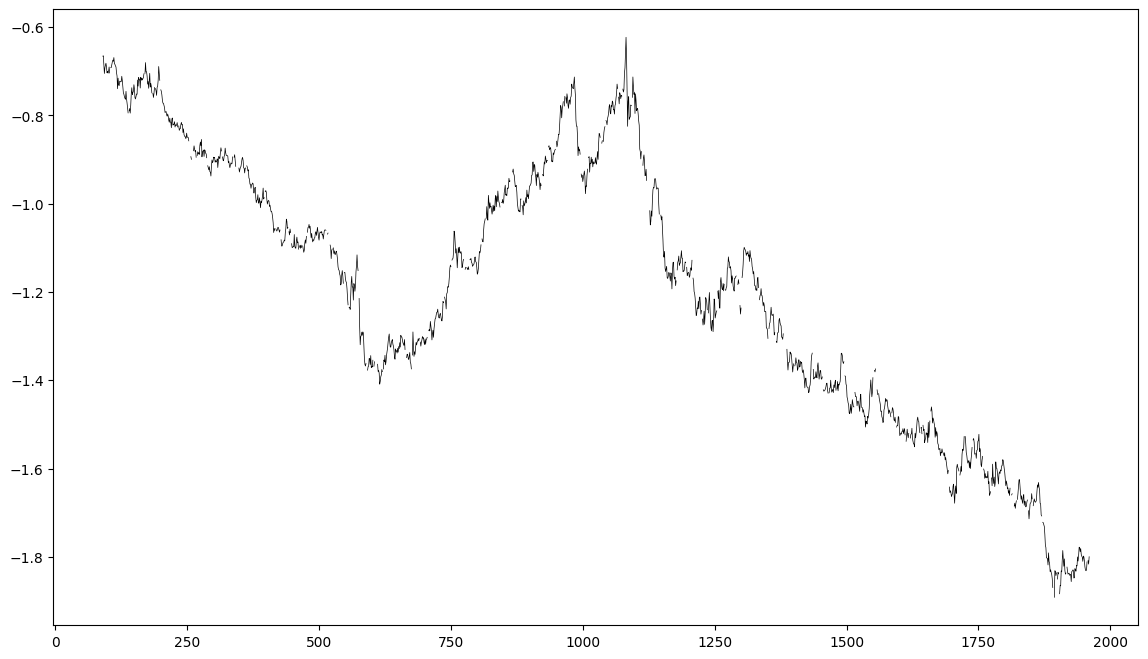

In [ ]:
plt.figure(figsize=(14, 8))
plt.plot(
    np.log(X_orig["LME_AH_Close"] / X_orig["JPX_Gold_Standard_Futures_Close"]),
    "k",
    lw=0.5,
)
plt.show()


In [ ]:
import lightgbm as lgb
from features import emadiff, rsi
from scipy.stats import pearsonr, spearmanr
from sklearn.model_selection import KFold
from supersmoother import SuperSmoother

feature_values = [
    # rsi(X_input, "lme_ah", span=15).values,
    # emadiff(X_input, "lme_ah_weighted_close", span=1).values,
    # emadiff(X_input, "lme_ah_weighted_close", span=5).values,
    # emadiff(X_input, "lme_ah_weighted_close", span=25).values,
    X_input["lme_ah_weighted_close"].values,
]

X_signals = np.stack(feature_values, axis=1)
y_signals = target_values.values


kf = KFold(n_splits=3, shuffle=False)

pearson_train_scores = []
spearman_train_scores = []
pearson_val_scores = []
spearman_val_scores = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X_signals)):
    X_tr, X_val = X_signals[train_idx], X_signals[val_idx]
    y_tr, y_val = y_signals[train_idx], y_signals[val_idx]

    model = lgb.LGBMRegressor(max_depth=3, verbose=-1, learning_rate=0.05)
    model.fit(X_tr, y_tr)

    y_tr_pred = model.predict(X_tr)
    y_val_pred = model.predict(X_val)

    # Only calculate scores on valid/finites
    tr_valid = np.isfinite(y_tr) & np.isfinite(y_tr_pred)
    val_valid = np.isfinite(y_val) & np.isfinite(y_val_pred)

    # Pearson
    if tr_valid.sum() > 0 and val_valid.sum() > 0:
        pearson_train = pearsonr(y_tr[tr_valid], y_tr_pred[tr_valid])[0]
        pearson_val = pearsonr(y_val[val_valid], y_val_pred[val_valid])[0]
    else:
        pearson_train = np.nan
        pearson_val = np.nan

    # Spearman
    if tr_valid.sum() > 0 and val_valid.sum() > 0:
        spearman_train = spearmanr(y_tr[tr_valid], y_tr_pred[tr_valid]).statistic
        spearman_val = spearmanr(y_val[val_valid], y_val_pred[val_valid]).statistic
    else:
        spearman_train = np.nan
        spearman_val = np.nan

    pearson_train_scores.append(pearson_train)
    pearson_val_scores.append(pearson_val)
    spearman_train_scores.append(spearman_train)
    spearman_val_scores.append(spearman_val)

    print(f"Fold {fold+1}")
    print(f"  Train Pearson:   {pearson_train:.4f}")
    print(f"  Train Spearman:  {spearman_train:.4f}")
    print(f"  Val   Pearson:   {pearson_val:.4f}")
    print(f"  Val   Spearman:  {spearman_val:.4f}")
    print("-" * 40)

print("Mean Train Pearson:", np.nanmean(pearson_train_scores))
print("Mean Train Spearman:", np.nanmean(spearman_train_scores))
print("Mean Val Pearson:", np.nanmean(pearson_val_scores))
print("Mean Val Spearman:", np.nanmean(spearman_val_scores))


Fold 1
  Train Pearson:   0.2547
  Train Spearman:  0.2352
  Val   Pearson:   0.0191
  Val   Spearman:  0.0341
----------------------------------------
Fold 2
  Train Pearson:   0.2894
  Train Spearman:  0.2731
  Val   Pearson:   -0.0500
  Val   Spearman:  -0.0688
----------------------------------------
Fold 3
  Train Pearson:   0.2669
  Train Spearman:  0.2632
  Val   Pearson:   -0.0132
  Val   Spearman:  -0.0064
----------------------------------------
Mean Train Pearson: 0.2703130292014668
Mean Train Spearman: 0.257189459888883
Mean Val Pearson: -0.014698439021196932
Mean Val Spearman: -0.01369844343365305


/Users/mike/.pyenv/versions/3.12.5/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/mike/.pyenv/versions/3.12.5/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/mike/.pyenv/versions/3.12.5/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/mike/.pyenv/versions/3.12.5/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/mike/.pyenv/versions/3.12.5/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, 

In [ ]:
print(X_input.shape)
print(X_primary.shape)
print(X_aux.shape)
print(Y_train.shape)
print(target_pairs.shape)


(1871, 610)
(1871, 103)
(1871, 501)
(1871, 425)
(424, 3)


In [ ]:
import dcor
import numpy as np
import pandas as pd
from scipy.stats import pearsonr, spearmanr

pearson_list = []
spearman_list = []

for col in X_input.columns:
    x = X_input[col].values
    y = target_values.values
    valid = np.isfinite(x) & np.isfinite(y)
    if valid.sum() == 0:
        pearson = np.nan
        spearman = np.nan
    else:
        pearson = abs(pearsonr(x[valid], y[valid])[0])
        spearman = abs(spearmanr(x[valid], y[valid]).statistic)
    pearson_list.append(pearson)
    spearman_list.append(spearman)

feature_stats_df = pd.DataFrame(
    {
        "feature": X_input.columns,
        "pearson": pearson_list,
        "spearman": spearman_list,
    }
).set_index("feature")
feature_stats_df = feature_stats_df.sort_values(by="spearman", ascending=False)

feature_stats_df.to_csv("feature_stats.csv")


In [ ]:
import lightgbm as lgb
from sklearn.model_selection import train_test_split

# 50/50 train/test split
X_tr, X_te, y_tr, y_te = train_test_split(
    X_input.values, target_values.values, test_size=0.5, random_state=42
)

model = lgb.LGBMRegressor(reg_alpha=0.5)
model.fit(X_tr, y_tr)

# Predict on test set
y_pred = model.predict(X_te)

# Compute Pearson and Spearman correlations on train set
y_tr_pred = model.predict(X_tr)
pearson_corr_train = pearsonr(y_tr, y_tr_pred)[0]
spearman_corr_train = spearmanr(y_tr, y_tr_pred).statistic

# Compute Pearson and Spearman correlations on test set
pearson_corr_test = pearsonr(y_te, y_pred)[0]
spearman_corr_test = spearmanr(y_te, y_pred).statistic

print(f"Train Pearson correlation: {pearson_corr_train:.4f}")
print(f"Train Spearman correlation: {spearman_corr_train:.4f}")
print(f"Test Pearson correlation: {pearson_corr_test:.4f}")
print(f"Test Spearman correlation: {spearman_corr_test:.4f}")


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003242 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 154062
[LightGBM] [Info] Number of data points in the train set: 935, number of used features: 610
[LightGBM] [Info] Start training from score 0.000106
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain

/Users/mike/.pyenv/versions/3.12.5/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/mike/.pyenv/versions/3.12.5/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Top 20 features by importance:
                                          feature  importance
450              us_stock_stld_adj_weighted_close         180
594               us_stock_xom_adj_weighted_close         150
150               us_stock_cvx_adj_weighted_close         150
13     jpx_gold_rolling-spot_futures_openinterest         120
377                      us_stock_paas_adj_volume          90
128             us_stock_ccj_adj_overnight_return          90
443                      us_stock_spyv_adj_volume          90
35   jpx_platinum_standard_futures_weighted_close          90
144               us_stock_cve_adj_weighted_close          90
309                   us_stock_kmi_adj_day_return          60
281                      us_stock_iemg_adj_volume          60
123                   us_stock_cat_adj_day_return          60
501                  us_stock_vcsh_adj_day_return          60
43    jpx_rss3_rubber_futures_intraday_volatility          60
100               us_stock_bnd_adj_clos

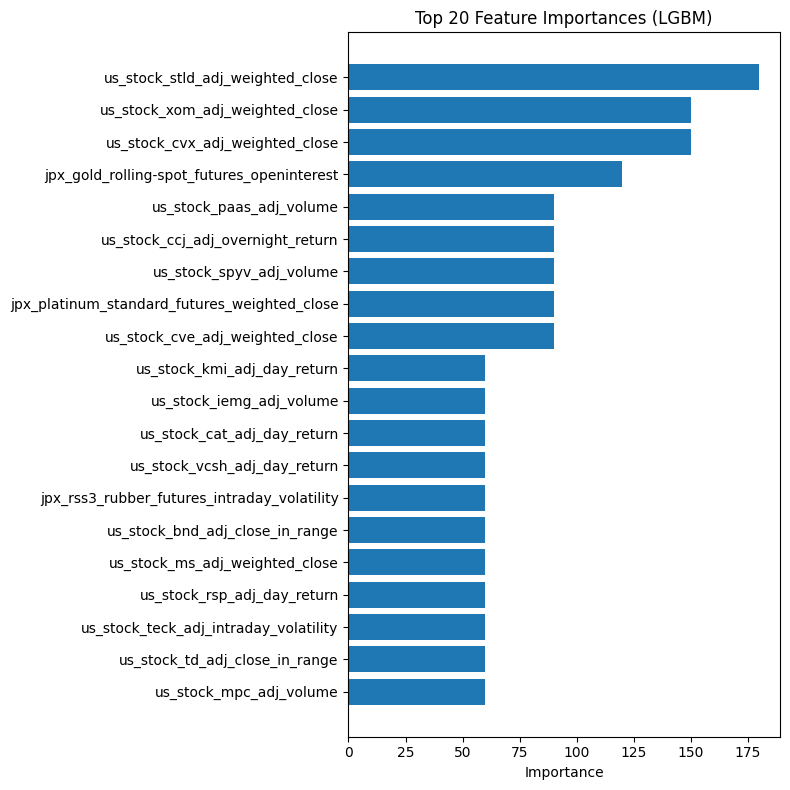


Top 10 Feature Pairs by SHAP Interaction Strength:
- dom x lme_ah_weighted_close: mean |interaction| = 0.0000
- dom x lme_ca_weighted_close: mean |interaction| = 0.0000
- dom x lme_pb_weighted_close: mean |interaction| = 0.0000
- dom x lme_zs_weighted_close: mean |interaction| = 0.0000
- dom x jpx_gold_mini_futures_volume: mean |interaction| = 0.0000
- dom x jpx_gold_mini_futures_openinterest: mean |interaction| = 0.0000
- dom x jpx_gold_mini_futures_weighted_close: mean |interaction| = 0.0000
- dom x jpx_gold_mini_futures_intraday_volatility: mean |interaction| = 0.0000
- dom x jpx_gold_mini_futures_overnight_return: mean |interaction| = 0.0000
- dom x jpx_gold_mini_futures_day_return: mean |interaction| = 0.0000


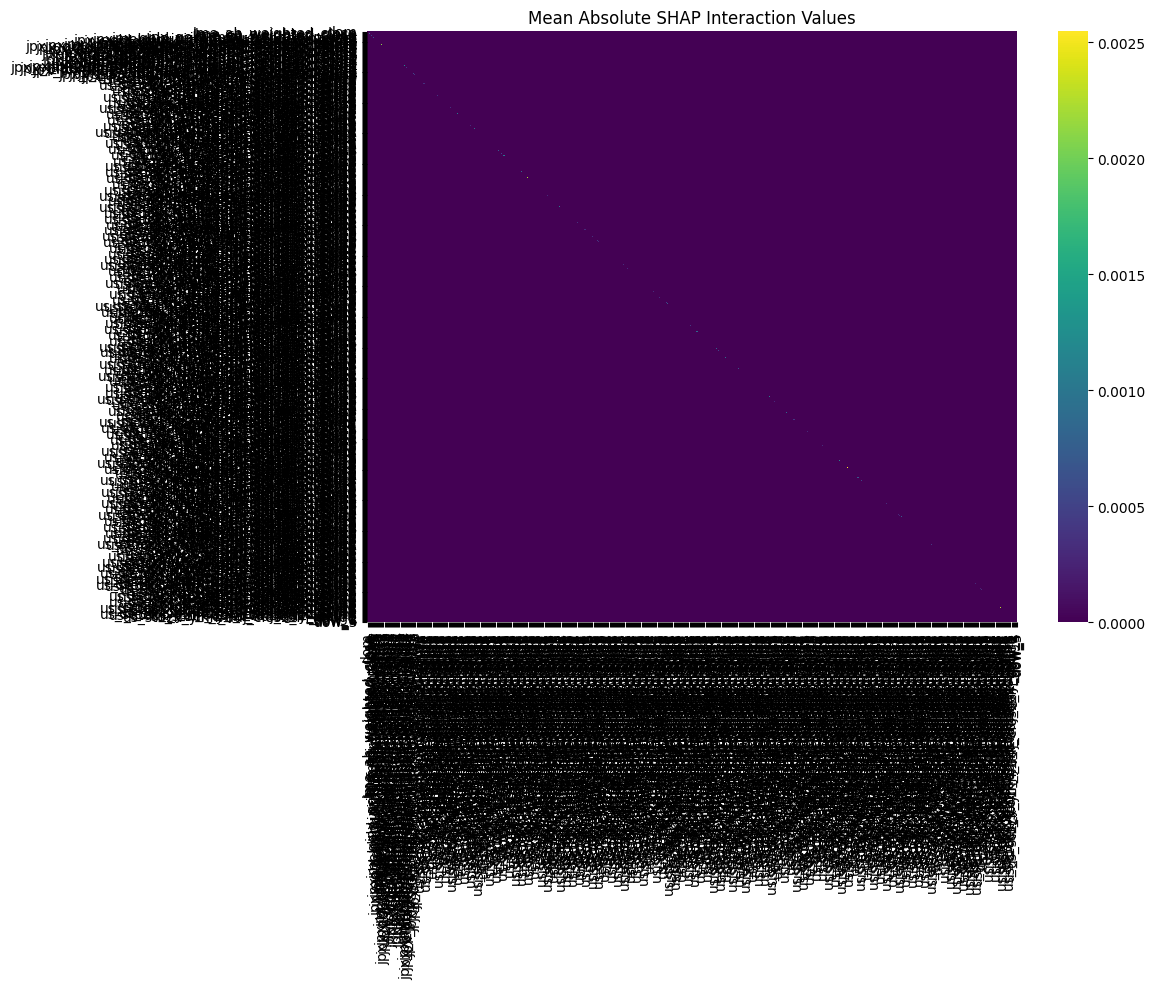

In [ ]:
import matplotlib.pyplot as plt
import shap

# Compute feature importances
importances = model.feature_importances_
feature_names = X_input.columns

# Make a DataFrame for easy sorting and inspection
importance_df = pd.DataFrame({"feature": feature_names, "importance": importances})
importance_df = importance_df.sort_values(by="importance", ascending=False)

print("Top 20 features by importance:")
print(importance_df.head(20))

# Plot the top 20 features
plt.figure(figsize=(8, 8))
plt.barh(
    importance_df.head(20)["feature"][::-1], importance_df.head(20)["importance"][::-1]
)
plt.title("Top 20 Feature Importances (LGBM)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

# --- PROPER INTERACTIONS: Use SHAP interaction values for true insight ---

explainer = shap.TreeExplainer(model)
# Use a small sample (e.g., 1000) for SHAP computation if dataset is large
sampled_X = X_input if len(X_input) < 1000 else X_input.sample(1000, random_state=42)
shap_interaction_values = explainer.shap_interaction_values(sampled_X)

# Calculate mean absolute interaction for each pair
import numpy as np

# For regression, shap_interaction_values is (n_samples, n_features, n_features)
# We'll aggregate abs mean over samples for each (i,j)
interaction_strength = np.abs(shap_interaction_values).mean(axis=0)

# Flatten and get top interaction pairs, ignoring self-interaction (diagonal)
interaction_pairs = []
for i in range(interaction_strength.shape[0]):
    for j in range(i + 1, interaction_strength.shape[1]):
        interaction_pairs.append(
            ((feature_names[i], feature_names[j]), interaction_strength[i, j])
        )
interaction_pairs = sorted(interaction_pairs, key=lambda x: -x[1])

print("\nTop 10 Feature Pairs by SHAP Interaction Strength:")
for (f1, f2), strength in interaction_pairs[:10]:
    print(f"- {f1} x {f2}: mean |interaction| = {strength:.4f}")

# Optionally, plot as a heatmap for better visualization
import seaborn as sns

plt.figure(figsize=(12, 10))
sns.heatmap(
    interaction_strength,
    annot=False,
    xticklabels=feature_names,
    yticklabels=feature_names,
    cmap="viridis",
)
plt.title("Mean Absolute SHAP Interaction Values")
plt.tight_layout()
plt.show()


In [ ]:
from collections import Counter

target_counter = Counter()
for _, row in target_pairs.iterrows():
    legs = row["pair"].split(" - ")
    target_counter.update(legs)

target_counter


Counter({'LME_AH_Close': 81,
         'LME_ZS_Close': 76,
         'JPX_Gold_Standard_Futures_Close': 74,
         'JPX_Platinum_Standard_Futures_Close': 71,
         'LME_CA_Close': 70,
         'LME_PB_Close': 68,
         'US_Stock_VT_adj_close': 5,
         'FX_ZARUSD': 5,
         'FX_NOKEUR': 5,
         'US_Stock_VXUS_adj_close': 5,
         'US_Stock_VYM_adj_close': 4,
         'US_Stock_IEMG_adj_close': 4,
         'FX_AUDJPY': 4,
         'US_Stock_VGIT_adj_close': 4,
         'FX_EURAUD': 4,
         'FX_CADCHF': 4,
         'FX_ZARCHF': 4,
         'FX_NZDJPY': 4,
         'FX_CHFJPY': 4,
         'US_Stock_VTV_adj_close': 4,
         'US_Stock_OIH_adj_close': 4,
         'FX_USDJPY': 4,
         'FX_AUDCHF': 4,
         'US_Stock_SLV_adj_close': 4,
         'US_Stock_BKR_adj_close': 4,
         'FX_GBPJPY': 4,
         'US_Stock_URA_adj_close': 4,
         'US_Stock_VEA_adj_close': 4,
         'FX_ZARJPY': 4,
         'US_Stock_OKE_adj_close': 4,
         'US_Stock_CVX_adj